In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Loading the dataset from the 'data' folder
df = pd.read_csv('Breast Cancer METABRIC.csv')

# Display the first 5 rows to make sure it loaded correctly
df.head()

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,...,Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,MB-0000,75.65,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,No,claudin-low,1.0,Positve,...,Living,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living
1,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1.0,Positve,...,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living
2,MB-0005,48.87,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,No,151.28,Recurred,Female,NaN,15.0,2.0,Died of Disease
3,MB-0006,47.68,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,Yes,LumB,1.0,Positve,...,Living,Positive,Yes,162.76,Not Recurred,Female,NaN,25.0,2.0,Living
4,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease


In [4]:
# Check for missing values and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2509 entries, 0 to 2508
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Patient ID                      2509 non-null   object 
 1   Age at Diagnosis                2498 non-null   float64
 2   Type of Breast Surgery          1955 non-null   object 
 3   Cancer Type                     2509 non-null   object 
 4   Cancer Type Detailed            2509 non-null   object 
 5   Cellularity                     1917 non-null   object 
 6   Chemotherapy                    1980 non-null   object 
 7   Pam50 + Claudin-low subtype     1980 non-null   object 
 8   Cohort                          2498 non-null   float64
 9   ER status measured by IHC       2426 non-null   object 
 10  ER Status                       2469 non-null   object 
 11  Neoplasm Histologic Grade       2388 non-null   float64
 12  HER2 status measured by SNP6    19

In [5]:
# Drop rows where our target variable is missing
df = df.dropna(subset=['Overall Survival Status'])

# Let's also drop 'Patient ID' since it's just a label and won't help the model
df.drop('Patient ID', axis=1, inplace=True)

print(f"Remaining rows after dropping missing targets: {df.shape[0]}")

Remaining rows after dropping missing targets: 1981


In [6]:
# Select numerical and categorical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill Numerical with Median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill Categorical with Mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check if any missing values remain
print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
0


In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# We will encode all categorical columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,ER Status,...,Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,75.65,1,0,2,0,0,6,1.0,1,1,...,1,0,1,138.65,0,0,2,22.0,2.0,2
1,43.19,0,0,2,0,0,2,1.0,1,1,...,1,1,1,83.52,0,0,0,10.0,1.0,2
2,48.87,1,0,2,0,1,3,1.0,1,1,...,0,1,0,151.28,1,0,1,15.0,2.0,0
3,47.68,1,0,5,2,1,3,1.0,1,1,...,1,1,1,162.76,0,0,1,25.0,2.0,2
4,76.97,1,0,5,0,1,3,1.0,1,1,...,0,1,1,18.55,1,0,0,40.0,2.0,0


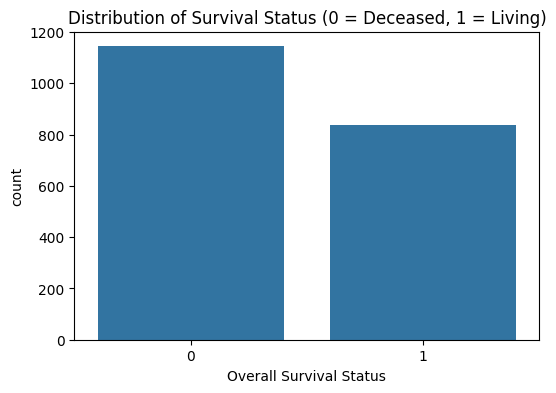

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Overall Survival Status', data=df)
plt.title('Distribution of Survival Status (0 = Deceased, 1 = Living)')
plt.show()

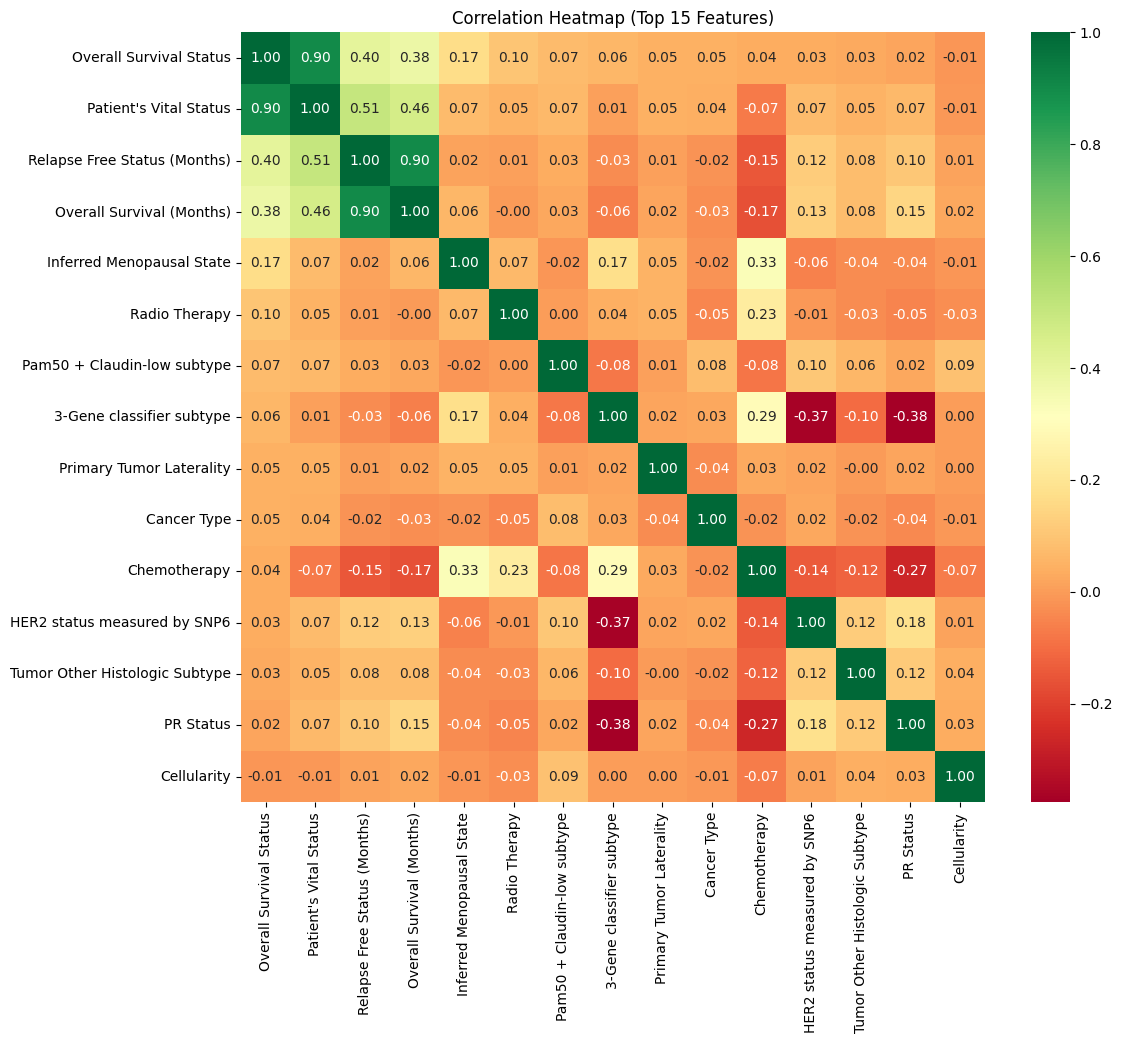

In [9]:
# Calculate correlation
corr_matrix = df.corr()

# Plotting the heatmap (top 15 features for clarity)
plt.figure(figsize=(12, 10))
top_corr_features = corr_matrix['Overall Survival Status'].sort_values(ascending=False).head(15).index
sns.heatmap(df[top_corr_features].corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Heatmap (Top 15 Features)')
plt.show()

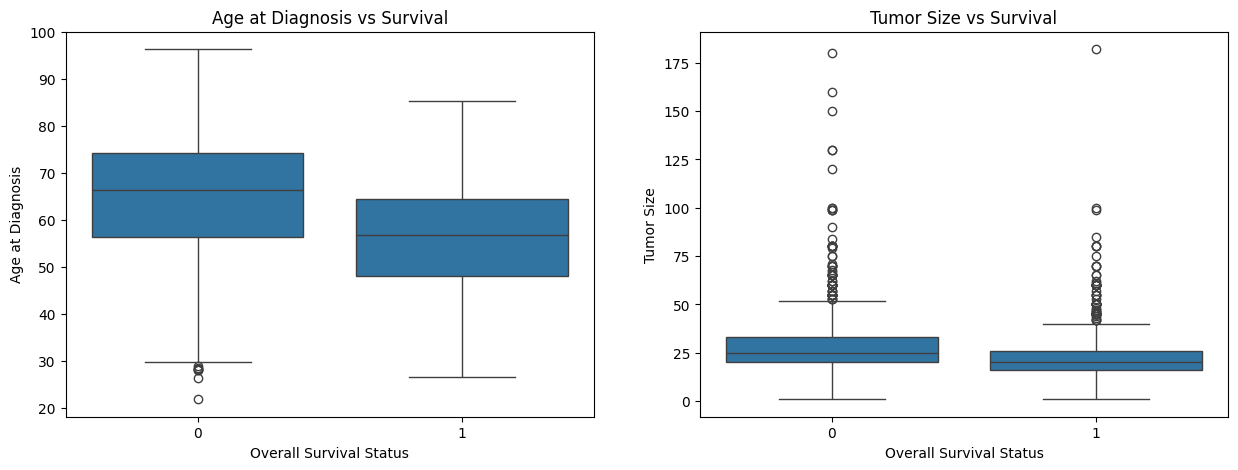

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Age vs Survival
sns.boxplot(x='Overall Survival Status', y='Age at Diagnosis', data=df, ax=axes[0])
axes[0].set_title('Age at Diagnosis vs Survival')

# Tumor Size vs Survival
sns.boxplot(x='Overall Survival Status', y='Tumor Size', data=df, ax=axes[1])
axes[1].set_title('Tumor Size vs Survival')

plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Define Features (X) and Target (y)
# We drop the target AND 'Patient's Vital Status' to avoid cheating
# We also drop 'Overall Survival (Months)' because we wouldn't know that for a new patient
X = df.drop(['Overall Survival Status', "Patient's Vital Status", 'Overall Survival (Months)'], axis=1)
y = df['Overall Survival Status']

# 2. Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Make Predictions
y_pred = rf_model.predict(X_test)

# 5. Evaluate the results
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.8060453400503779

Confusion Matrix:
 [[199  34]
 [ 43 121]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.84       233
           1       0.78      0.74      0.76       164

    accuracy                           0.81       397
   macro avg       0.80      0.80      0.80       397
weighted avg       0.81      0.81      0.81       397



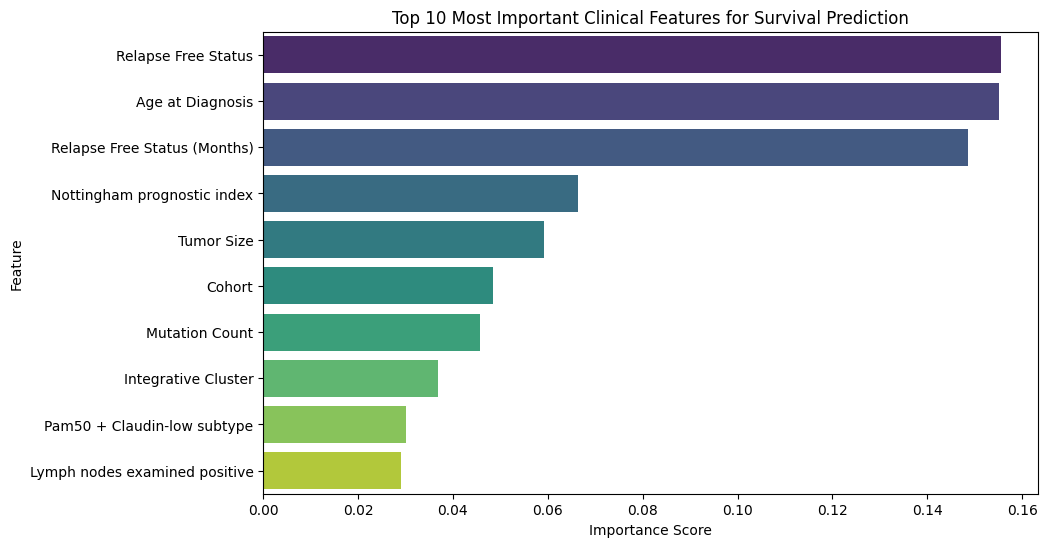

Top 5 Features driving the model:
                         Feature  Importance
25           Relapse Free Status    0.155571
0               Age at Diagnosis    0.155161
24  Relapse Free Status (Months)    0.148660
20   Nottingham prognostic index    0.066274
28                    Tumor Size    0.059173


In [14]:
 1. Get Feature Importances from the Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns

# 2. Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Updated plotting code to remove the warning
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df.head(10), 
    hue='Feature',      # Assigning hue to the y variable
    palette='viridis', 
    legend=False        ## Hiding the legend for a cleaner look
)
plt.title('Top 10 Most Important Clinical Features for Survival Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

# 4. Display the top features as text
print("Top 5 Features driving the model:")
print(feature_importance_df.head(5))

In [15]:
import joblib

# 1. Save the trained model to a file
joblib.dump(rf_model, 'breast_cancer_model.pkl')

# 2. Save the encoder (so we can handle new data later)
# Assuming 'le' was your LabelEncoder from earlier
# joblib.dump(le, 'label_encoder.pkl') 

print("Model saved successfully as 'breast_cancer_model.pkl'!")

Model saved successfully as 'breast_cancer_model.pkl'!
